# Notebook 24 — FINAL HTR PRODUCT: Inference & Demo

In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
from pathlib import Path
from collections import defaultdict
import numpy as np, pandas as pd
from PIL import Image
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import matplotlib.pyplot as plt

DEVICE = (torch.device("mps") if torch.backends.mps.is_available()
          else torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Using device: {DEVICE}")

DATA_ROOT = Path("../data/pharmacy_lk")
TRAIN_CSV = DATA_ROOT/"splits/train.csv"
AUG_CKPT = Path("../checkpoints/trocr_augmented/best")
PROC = "microsoft/trocr-small-handwritten"
FORMULARY_CSV = Path("../data/formulary/drug_names.csv")
LABEL_COL = "medicine_name"; IMG_COL = "image_filename"
TAU = 0.4   # formulary snap threshold (same as evaluated)

Using device: mps


## 1. Load the formulary (training names UNIONED with external list)

In [2]:
def edit_distance(a, b):
    if a == b: return 0
    if not a: return len(b)
    if not b: return len(a)
    prev = list(range(len(b)+1))
    for i, ca in enumerate(a, 1):
        cur=[i]
        for j, cb in enumerate(b, 1):
            cur.append(min(prev[j]+1, cur[j-1]+1, prev[j-1]+(ca!=cb)))
        prev=cur
    return prev[-1]

train_names = set(pd.read_csv(TRAIN_CSV)[LABEL_COL].astype(str).str.strip().str.lower())
if FORMULARY_CSV.exists():
    ext = pd.read_csv(FORMULARY_CSV)
    col = "drug_name" if "drug_name" in ext.columns else ext.columns[0]
    formulary = sorted((set(ext[col].astype(str).str.strip().str.lower()) - {""}) | train_names)
    print(f"formulary loaded: {len(formulary)} names")
else:
    formulary = sorted(train_names)
    print(f"!! external formulary not found — using training names only ({len(formulary)})")

by_len = defaultdict(list)
for w in formulary: by_len[len(w)].append(w)

def nearest(word, gap=3):
    if not word: return None, 10**9
    if word in by_len.get(len(word), ()): return word, 0
    best, bd = None, 10**9
    for L in range(len(word)-gap, len(word)+gap+1):
        for e in by_len.get(L, ()):
            d = edit_distance(word, e)
            if d < bd: best, bd = e, d
            if bd == 1: return best, bd
    return best, bd

def formulary_snap(word, tau=TAU):
    e, d = nearest(word)
    return e if (e is not None and d/max(len(word),1) <= tau) else word

formulary loaded: 4779 names


## 2. Load the Augmented TrOCR model

In [3]:
processor = TrOCRProcessor.from_pretrained(PROC)
model = VisionEncoderDecoderModel.from_pretrained(AUG_CKPT).to(DEVICE).eval()
print("Augmented TrOCR loaded")

Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

Augmented TrOCR loaded


## 3. THE PRODUCT — a single clean function
`predict_medicine_name(pil_image)` -> final medicine name (recognition + formulary).
This is the function the full pipeline (segmentation -> HTR) will call.

In [4]:
def predict_medicine_name(pil_image, return_detail=False):
    """Finalised HTR product: image -> augmented TrOCR -> formulary normalisation -> name."""
    pv = processor(pil_image.convert("RGB"), return_tensors="pt").pixel_values.to(DEVICE)
    with torch.no_grad():
        ids = model.generate(pv, max_new_tokens=24)
    raw = processor.decode(ids[0], skip_special_tokens=True).strip().lower()
    final = formulary_snap(raw)
    if return_detail:
        return {"raw_recognition": raw, "final_name": final,
                "was_corrected": raw != final}
    return final

## 4. >>> TEST CHOSEN IMAGES <<<  (image + predicted + true name)
List image FILENAMES from your dataset. The true name is looked up from the splits.

  173478_0_med_2.jpg             | raw: emeset             | pred: emeset             | true: emeset             | OK
  173658_0_med_1.jpg             | raw: clasuvas           | pred: clavam             | true: cartisafe-od       | X
  173698_0_med_3.jpg             | raw: orofer             | pred: orofer             | true: orofer             | OK
  173761_0_med_1.jpg             | raw: nucoxia            | pred: nucoxia            | true: nucoxia            | OK
  192605_1_med_1.jpg             | raw: abasaglar          | pred: abasaglar          | true: abasaglar          | OK
  192631_2_med_2.jpg             | raw: actrafid           | pred: actrafid           | true: actrafid           | OK
  192632_0_med_3.jpg             | raw: actrapid           | pred: actrapid           | true: actrapid           | OK
  192865_0_med_2.jpg             | raw: ansef              | pred: ansef              | true: ansef              | OK


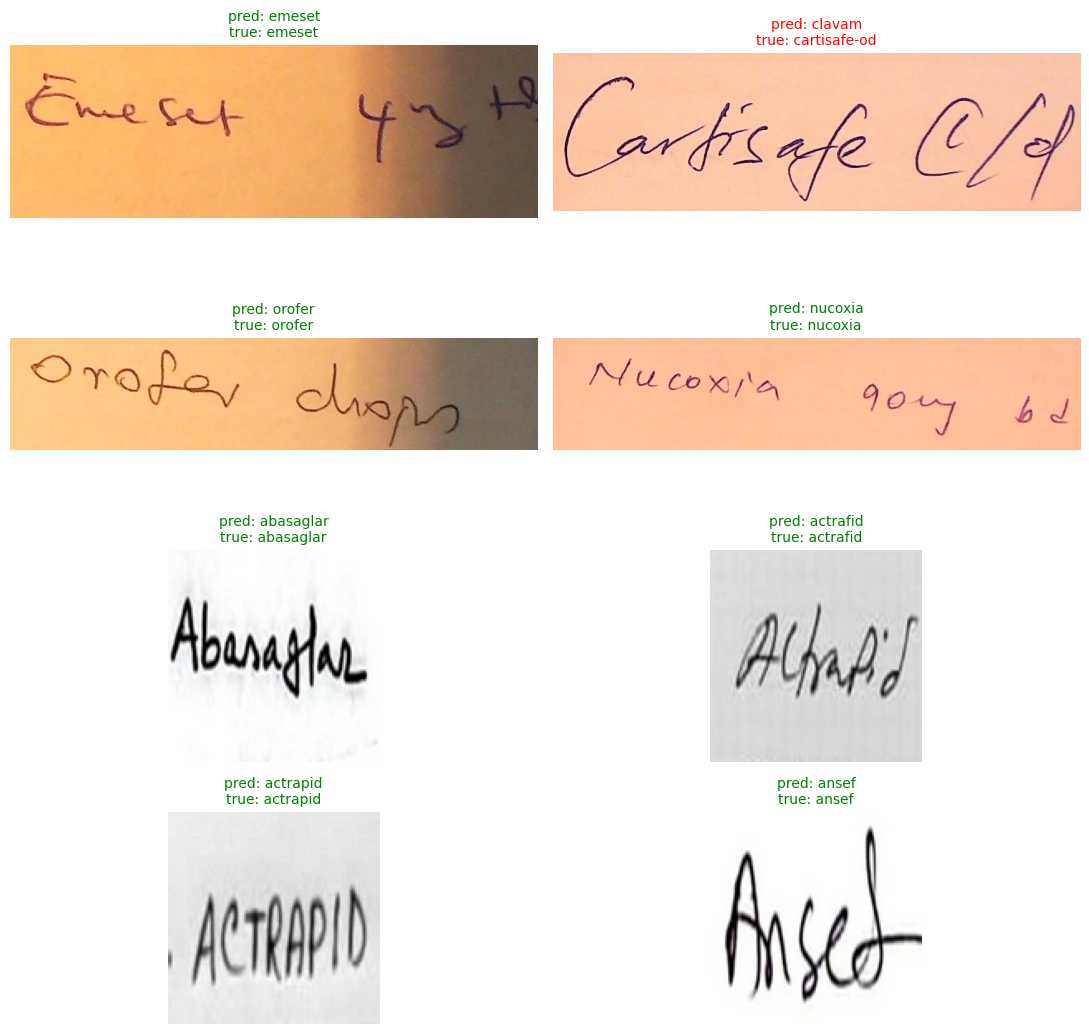


saved demo predictions -> reports/tables/final_product_demo.csv


In [5]:
CHOSEN_IMAGES = [
    "173478_0_med_2.jpg",
    "173658_0_med_1.jpg",
    "173698_0_med_3.jpg",
    "173761_0_med_1.jpg",
    "192605_1_med_1.jpg",
    "192631_2_med_2.jpg",
    "192632_0_med_3.jpg",
    "192865_0_med_2.jpg"



    # "REPLACE_WITH_YOUR_IMAGE.jpg",
    # add 5-6 filenames here
]

# build filename -> true label lookup across all splits
lookup = {}
for split in ["splits/train.csv", "splits/val.csv", "splits/test.csv"]:
    p = DATA_ROOT/split
    if p.exists():
        d = pd.read_csv(p)
        for _, r in d.iterrows():
            lookup[str(r[IMG_COL])] = str(r[LABEL_COL]).strip().lower()

panels, rows = [], []
for fname in CHOSEN_IMAGES:
    ip = DATA_ROOT/"images"/fname
    if not ip.exists():
        print(f"  [missing] {fname}"); continue
    pil = Image.open(ip)
    detail = predict_medicine_name(pil, return_detail=True)
    true = lookup.get(fname, "(no annotation)")
    ok = (detail["final_name"] == true)
    panels.append((pil, detail, true, ok))
    rows.append({"image": fname, "raw": detail["raw_recognition"],
                 "predicted": detail["final_name"], "true": true, "correct": ok})
    print(f"  {fname:30s} | raw: {detail['raw_recognition']:18s} | "
          f"pred: {detail['final_name']:18s} | true: {true:18s} | {'OK' if ok else 'X'}")

# visual grid
if panels:
    n=len(panels); cols=2; rowsN=(n+cols-1)//cols
    fig, axes = plt.subplots(rowsN, cols, figsize=(cols*5.5, rowsN*2.6))
    axes = np.array(axes).reshape(-1)
    for ax,(pil,detail,true,ok) in zip(axes, panels):
        ax.imshow(pil, cmap="gray"); ax.axis("off")
        c = "green" if ok else "red"
        ax.set_title(f"pred: {detail['final_name']}\ntrue: {true}", fontsize=10, color=c)
    for ax in axes[len(panels):]: ax.axis("off")
    plt.tight_layout(); plt.show()
    pd.DataFrame(rows).to_csv("../reports/tables/final_product_demo.csv", index=False)
    print(f"\nsaved demo predictions -> reports/tables/final_product_demo.csv")
else:
    print("Add image filenames to CHOSEN_IMAGES above to run the visual test.")

## 5. Single-image quick test (point at any one image)

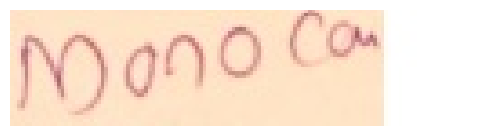

raw recognition : macrocor
FINAL NAME      : atocor
formulary corrected: True


In [12]:
SINGLE_IMAGE = "../data/test/176805_1_line_007.jpg"
sp = Path(SINGLE_IMAGE)
if sp.exists():
    pil = Image.open(sp)
    plt.figure(figsize=(6,2.2)); plt.imshow(pil, cmap="gray"); plt.axis("off"); plt.show()
    d = predict_medicine_name(pil, return_detail=True)
    print(f"raw recognition : {d['raw_recognition']}")
    print(f"FINAL NAME      : {d['final_name']}")
    print(f"formulary corrected: {d['was_corrected']}")
else:
    print("Set SINGLE_IMAGE to a real path to quick-test one image.")